# Screen Diffraction of individual Electrons
1. Examine the diffraction pattern of a line of electrons passing through a wakefield. this model uses ballistic trajectories.
2. Animation

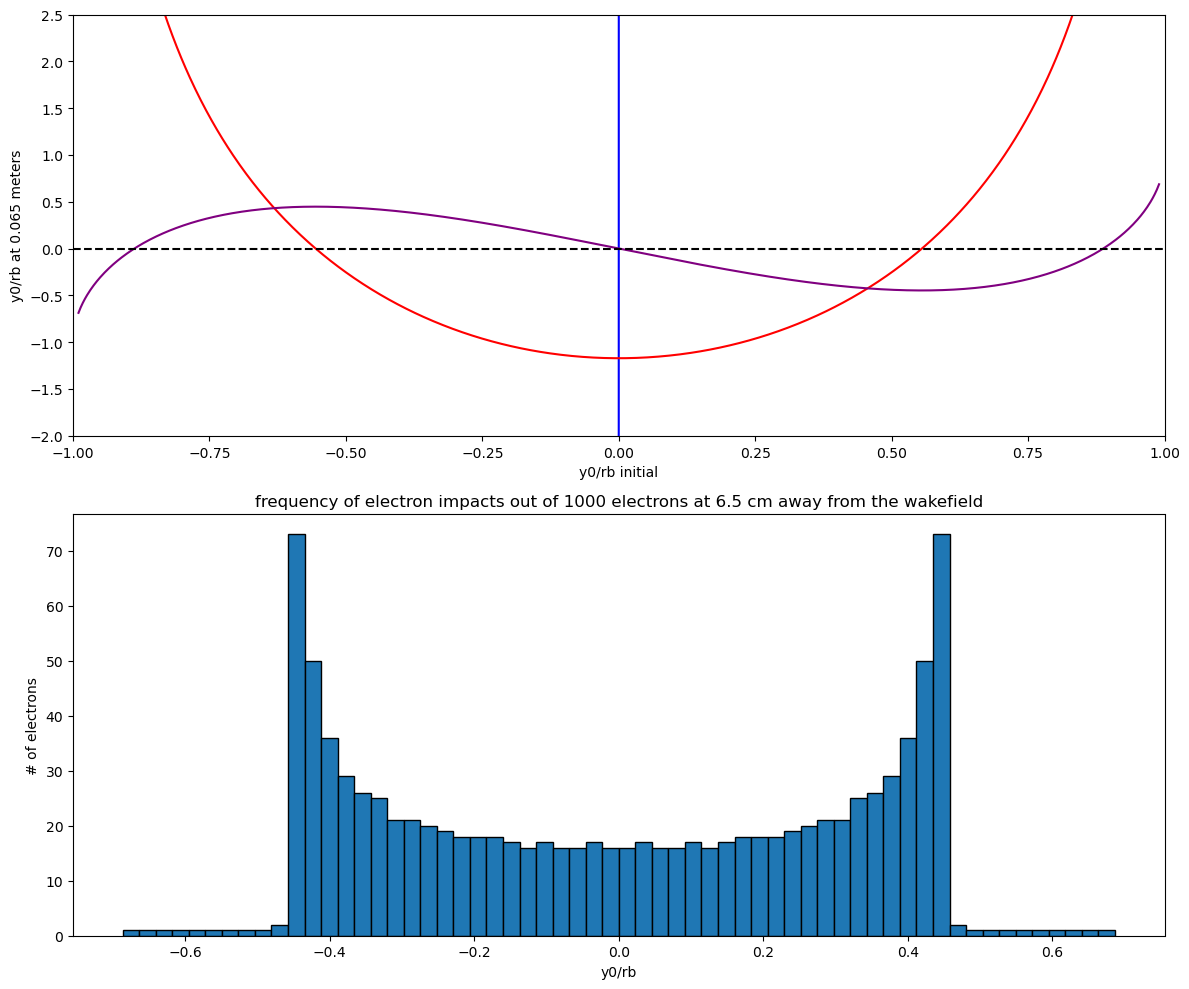

In [1]:
#Bryson Mariano
#6/1/2026

import numpy as np
import scipy.constants as constants
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import math

#Universal Parameters
me    = 9.1093837 * 10 ** (-31)  #kg
c     = 299792458.0              #m/s
ne    = 1 * 10.0**15 *10**6                 #number density
e0    = 8.85418782 * 10**(-12)   #m^-3 kg^-1s^4 A^2
e     = 1.60217663 * 10**(-19)   #coulombs
wp    = ((ne*e**2)/(me*e0)) ** (1/2)


#Define Parameters


gamma = 110                      #Unitless
k     = 0.475 *me*wp**2          #kg/s^2
rb    = 0.65  *c/wp               #c/omega_p   
px    = 110   *me*c                #mec

f0=((px)**2) / (gamma * me * k)


################################################################


################################################################
#Create/define Focal Length Function

def f_cyl(i):
    return ( f0/(2*rb) *1/(np.sqrt(1-(i/rb)**2)))

def f_cylprime(i):
    return ( f0 /(2*rb) * (1-(i/rb)**2)**(-3/2) * (i/rb**2)  )

def f_cylprimeprime(i):
    return ( f0 /(2*rb**3) * (1-(i/rb)**2)**(-3/2) + 3*f0*i**2 /(2*rb**5) * (1-(i/rb)**2)**(-5/2)    )
              


N=1000                 #Number of Electrons
distance = 0.065      # Slice Distance


y0rb = np.linspace( -0.99, 0.99, N)




electron   = -(y0rb*rb/(f_cyl(y0rb*rb)))*distance +y0rb*rb

d_electron = 1-(distance)/f_cyl(y0rb*rb)+(y0rb*rb*distance)*f_cylprime(y0rb*rb)/f_cyl(y0rb*rb)**2

dd_electron= (2*(distance)*f_cylprime(y0rb*rb)/(f_cyl(y0rb*rb)**2)- 2*(y0rb*rb)*distance*f_cylprime(y0rb*rb)**2/(f_cyl(y0rb*rb)**3) +
              (y0rb*rb)*distance*f_cylprimeprime(y0rb*rb)/(f_cyl(y0rb*rb)**2) )
              
arr=electron/rb


arr2=d_electron

arr3=dd_electron

np.set_printoptions(suppress=True, precision=4)


plt.figure(figsize=(12,10))

plt.subplot(2,1,1)
plt.plot(y0rb, arr3, 'blue')     
plt.plot(y0rb, arr2, 'red')     
plt.plot(y0rb, arr, 'purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.xlim(-1, 1)
plt.ylim(-2,2.5)
plt.ylabel(f"y0/rb at {distance} meters")
plt.xlabel("y0/rb initial")



plt.subplot(2,1,2)
plt.hist(arr, bins=60, edgecolor='black')
plt.xlabel('y0/rb')
plt.ylabel(f'# of electrons')
plt.title(f'frequency of electron impacts out of {N} electrons at {distance*100} cm away from the wakefield')


plt.tight_layout()
plt.show()


##  2.Animation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.animation import PillowWriter
import matplotlib.animation as animation
from matplotlib.animation import HTMLWriter
#import shutil
#print(shutil.which("ffmpeg"))

# Universal Parameters
me = 9.1093837e-31
c = 299792458.0
ne = 1e15 * 1e6
e0 = 8.85418782e-12
e = 1.60217663e-19

# Define Parameters
wp = np.sqrt((ne*e**2)/(me*e0))
gamma = 110
k = 0.475 * me * wp**2
rb = 0.65 * c/wp
px = 110 * me * c
f0 = px**2/(gamma*me*k)
##################################################

def f_cyl(i):
    return f0/(2*rb) * 1/np.sqrt(1-(i/rb)**2)

##################################################

N = 1000                 #Number of Electrons
distance = 0.065         #Distance from Wakefield

##################################################


# t values to animate
t_values = np.linspace(-1, 0, 100)

fig, ax = plt.subplots()




def update(frame):

    t = t_values[frame]

    y0rb = np.linspace(t, 0.99, N)

    electron = (-(y0rb*rb/f_cyl(y0rb*rb))*distance+ y0rb*rb)

    arr = electron/rb

    ax.clear()
    ax.hist(arr, bins=60, edgecolor='black')

    ax.set_xlabel('y0/rb')
    ax.set_ylabel('# of electrons')
    ax.set_xlim(-1, 1)
    ax.set_title(f't = {t:.3f}')

    ax.text(
    0.02, 0.95,
    rf'$y_{{0,\min}}/r_b = {t:.3f}$',
    transform=ax.transAxes,
    fontsize=14,
    verticalalignment='top',
    bbox=dict(boxstyle='round', alpha=0.8) 
    )

ani = FuncAnimation(
    fig,
    update,
    frames=len(t_values),
    interval=100,
    repeat=True
)

ani.save("electron_histogram.html",writer="html")
plt.close()
HTML(ani.to_jshtml())



C:\Users\bryso\AppData\Local\Temp\ipykernel_26216\3492836243.py:28: RuntimeWarning: divide by zero encountered in divide
  return f0/(2*rb) * 1/np.sqrt(1-(i/rb)**2)
C:\Users\bryso\AppData\Local\Temp\ipykernel_26216\3492836243.py:28: RuntimeWarning: divide by zero encountered in divide
  return f0/(2*rb) * 1/np.sqrt(1-(i/rb)**2)
